## Практика. Метрики прогнозирующих моделей

In [1]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning) 

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import seaborn as sns
sns.set_style("whitegrid")

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.metrics import confusion_matrix
from sklearn.metrics import RocCurveDisplay

>#### Задание 1
Прочитайте файл `strong_spirit`.

In [2]:
df = pd.read_csv('data/strong_spirit.csv')
df 

,age,gender,membership_months,distance_to_club,trainer_exp,num_visits_last_30d,avg_session_duration,group_lesson,calories_burned,high_intensity,early_renewal
0,56,1,18,10.4,61,4,48.4,0,446,0,0
1,69,0,22,14.0,50,2,91.7,0,576,0,0
2,46,0,22,9.5,69,9,83.5,0,640,1,1
3,32,1,1,12.2,0,6,28.1,0,322,0,0
4,60,0,17,1.7,119,8,31.5,0,362,0,1
...,...,...,...,...,...,...,...,...,...,...,...
1995,37,0,24,8.5,0,4,90.1,0,587,0,0
1996,39,0,9,7.1,1,9,119.0,1,800,1,0
1997,28,0,20,3.0,0,5,113.5,0,693,1,0
1998,44,1,7,9.7,0,6,73.3,1,579,1,0


#### Контекст

Сеть фитнес-клубов «Сильные Духом» (StrongSpirit) хочет улучшить удержание клиентов и оптимизировать нагрузку на тренеров. Система посещений фиксирует каждый визит, и накоплено много данных.


#### Датасет
- age	— возраст клиента (18–70) (int),
- gender — пол клиента (0 — женский, 1 — мужской) (int),
- membership_months — длительность действующего абонемента в месяцах (1–24) (int),
- distance_to_club — расстояние от дома до клуба в километрах	(0.5–15.0) (float),
- trainer_exp — стаж персонального тренера в месяцах, если есть; 0 — нет тренера (0–120) (int),
- num_visits_last_30d — количество посещений за последние 30 дней (0–30) (int),
- avg_session_duration — средняя продолжительность тренировки в минутах (20–120) (float)
- group_lesson — посещал ли групповые занятия за последние 30 дней (0 — нет, 1 — да) (int),

#### Таргеты
- calories_burned — среднее количество сожжённых калорий за тренировку (150–800 ккал) (float).

- high_intensity — интенсивность тренировок (0 — не высокая интенсивность, 1 — высокая интенсивность) (int).

- early_renewal — продлил ли клиент абонемент (0/1).


#### Бизнес-задача
- Прогнозировать `calories_burned` — чтобы персонализировать программы тренировок, предлагать клиентам цели и отслеживать прогресс.
- Классифицировать `high_intensity` — чтобы планировать нагрузку на тренеров и оборудование, а также корректировать расписание групповых занятий.
- Предсказывать `early_renewal` — чтобы выделять клиентов «группы лояльности» и отправлять им персонализированные предложения до истечения срока абонемента.

>#### Задание 2
Обучите регрессионную модель, которая прогнозирует расход калорий. Вычислите ее метрики на train'е и на test'е. При вычислении метрик используйте 1) ручной подсчет по определению, 2) методы билиотеки sklearn. Убедитесь, что метрики совпадают с точностью до шестого знака после запятой.

In [3]:
X = df.drop(columns = ['calories_burned'])
y = df['calories_burned']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [4]:
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

#### MAE

In [5]:
MAE_train_manual = round(np.mean(abs(y_train - y_train_pred)), 6)
print('MAE_train_manual:', MAE_train_manual)

MAE_test_manual = round(np.mean(abs(y_test - y_test_pred)), 6)
print('MAE_test_manual:', MAE_test_manual)

MAE_train_sklearn = round(mean_absolute_error(y_train, y_train_pred), 6)
print('MAE_train_sklearn:', MAE_train_sklearn)

MAE_test_sklearn = round(mean_absolute_error(y_test, y_test_pred), 6)
print('MAE_test_sklearn:', MAE_test_sklearn)

MAE_train_manual == MAE_train_sklearn, MAE_test_manual == MAE_test_sklearn

MAE_train_manual: 45.60522
MAE_test_manual: 46.267761
MAE_train_sklearn: 45.60522
MAE_test_sklearn: 46.267761


(True, True)

#### MSE

In [6]:
MSE_train_manual = round(np.mean((y_train - y_train_pred)**2), 6)
print('MSE_train_manual:', MSE_train_manual)

MSE_test_manual = round(np.mean((y_test - y_test_pred)**2), 6)
print('MSE_test_manual:', MSE_test_manual)

MSE_train_sklearn = round(mean_squared_error(y_train, y_train_pred), 6)
print('MSE_train_sklearn:', MSE_train_sklearn)

MSE_test_sklearn = round(mean_squared_error(y_test, y_test_pred), 6)
print('MSE_test_sklearn:', MSE_test_sklearn)

MSE_train_manual == MSE_train_sklearn, MSE_test_manual == MSE_test_sklearn

MSE_train_manual: 3251.362053
MSE_test_manual: 3348.346525
MSE_train_sklearn: 3251.362053
MSE_test_sklearn: 3348.346525


(True, True)

#### RMSE

In [7]:
RMSE_train_manual = round((np.mean((y_train - y_train_pred)**2))**0.5, 6)
print('RMSE_train_manual:', RMSE_train_manual)

RMSE_test_manual = round((np.mean((y_test - y_test_pred)**2))**0.5, 6)
print('RMSE_test_manual:', RMSE_test_manual)

RMSE_train_manual: 57.020716
RMSE_test_manual: 57.864899


#### R<sup>2</sup>

In [8]:
r2_train_manual = round(1 - np.sum((y_train - y_train_pred)**2)/np.sum((y_train - np.mean(y_train))**2), 6)
print('r2_train_manual:', r2_train_manual)

r2_test_manual = round(1 - np.sum((y_test - y_test_pred)**2)/np.sum((y_test - np.mean(y_test))**2), 6)
print('r2_test_manual:', r2_test_manual)

r2_train_sklearn = round(r2_score(y_train, y_train_pred), 6)
print('r2_train_sklearn:', r2_train_sklearn)

r2_test_sklearn = round(r2_score(y_test, y_test_pred), 6)
print('r2_test_sklearn:', r2_test_sklearn)

r2_train_manual == r2_train_sklearn, r2_test_manual == r2_test_sklearn

r2_train_manual: 0.809415
r2_test_manual: 0.798883
r2_train_sklearn: 0.809415
r2_test_sklearn: 0.798883


(True, True)

>#### Задание 3
Обучите бинарный классификатор, который прогнозирует интенсивность тренировок. Вычислите его метрики на train'е и на test'е. При вычислении метрик используйте 1) ручной подсчет по определению, 2) методы билиотеки sklearn. Убедитесь, что метрики совпадают с точностью до шестого знака после запятой.

In [9]:
X = df.drop(columns = ['high_intensity'])
y = df['high_intensity']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

knn = KNeighborsClassifier()
knn.fit(X_train, y_train)

KNeighborsClassifier()

In [10]:
y_train_pred = knn.predict(X_train)
y_test_pred = knn.predict(X_test)

#### Confusion matrix

In [11]:
TP_train = sum((y_train == 1) & (y_train_pred == 1))
TN_train = sum((y_train == 0) & (y_train_pred == 0))
FP_train = sum((y_train == 0) & (y_train_pred == 1))
FN_train = sum((y_train == 1) & (y_train_pred == 0))

CM_train_manual = np.array([[TP_train, FP_train],
                     [FN_train, TN_train]])

print('CM_train_manual =')
print(CM_train_manual)

TP_test = sum((y_test == 1) & (y_test_pred == 1))
TN_test = sum((y_test == 0) & (y_test_pred == 0))
FP_test = sum((y_test == 0) & (y_test_pred == 1))
FN_test = sum((y_test == 1) & (y_test_pred == 0))

CM_test_manual = np.array([[TP_test, FP_test],
                     [FN_test, TN_test]])

print('')
print('CM_test_manual =')
print(CM_test_manual)

CM_train_sklearn = confusion_matrix(y_train, y_train_pred)

print('')
print('CM_train_sklearn =')
print(CM_train_sklearn)

CM_test_sklearn = confusion_matrix(y_test, y_test_pred)

print('')
print('CM_test_sklearn =')
print(CM_test_sklearn)

CM_train_manual =
[[660  53]
 [ 59 728]]

CM_test_manual =
[[202  36]
 [ 35 227]]

CM_train_sklearn =
[[728  53]
 [ 59 660]]

CM_test_sklearn =
[[227  36]
 [ 35 202]]


#### Accuracy

In [12]:
accuracy_train_manual = round((TP_train + TN_train)/(TP_train + TN_train + FP_train + FN_train), 6)
print('accuracy_train_manual =', accuracy_train_manual)

accuracy_test_manual = round((TP_test + TN_test)/(TP_test + TN_test + FP_test + FN_test), 6)
print('accuracy_test_manual =', accuracy_test_manual)

accuracy_train_sklearn = round(accuracy_score(y_train_pred, y_train), 6)
print('accuracy_train_sklearn =', accuracy_train_sklearn)

accuracy_test_sklearn = round(accuracy_score(y_test_pred, y_test), 6)
print('accuracy_test_sklearn =', accuracy_test_sklearn)

accuracy_train_manual == accuracy_train_sklearn, accuracy_test_manual == accuracy_test_sklearn

accuracy_train_manual = 0.925333
accuracy_test_manual = 0.858
accuracy_train_sklearn = 0.925333
accuracy_test_sklearn = 0.858


(True, True)

#### Precission

In [13]:
precission_train_manual = round(TP_train/(TP_train + FP_train), 6)
print('precission_train_manual =', precission_train_manual)

precission_test_manual = round(TP_test/(TP_test + FP_test), 6)
print('precission_test_manual =', precission_test_manual)

precission_train_sklearn = round(precision_score(y_train, y_train_pred), 6)
print('precission_train_sklearn =', precission_train_sklearn)

precission_test_sklearn = round(precision_score(y_test, y_test_pred), 6)
print('precission_test_sklearn =', precission_test_sklearn)

precission_train_manual == precission_train_sklearn, precission_test_manual == precission_test_sklearn

precission_train_manual = 0.925666
precission_test_manual = 0.848739
precission_train_sklearn = 0.925666
precission_test_sklearn = 0.848739


(True, True)

#### Recall

In [14]:
recall_train_manual = round(TP_train/(TP_train + FN_train), 6)
print('recall_train_manual =', recall_train_manual)

recall_test_manual = round(TP_test/(TP_test + FN_test), 6)
print('recall_test_manual =', recall_test_manual)

recall_train_sklearn = round(recall_score(y_train, y_train_pred), 6)
print('recall_train_sklearn =', recall_train_sklearn)

recall_test_sklearn = round(recall_score(y_test, y_test_pred), 6)
print('recall_test_sklearn =', recall_test_sklearn)

recall_train_manual == recall_train_sklearn, recall_test_manual == recall_test_sklearn

recall_train_manual = 0.917942
recall_test_manual = 0.852321
recall_train_sklearn = 0.917942
recall_test_sklearn = 0.852321


(True, True)

#### F1 

In [15]:
f1_train_manual = round(2*(precission_train_manual * recall_train_manual)/(precission_train_manual + recall_train_manual), 6)
print('f1_train_manual =', f1_train_manual)

f1_test_manual = round(2*(precission_test_manual * recall_test_manual)/(precission_test_manual + recall_test_manual), 6)
print('f1_test_manual =', f1_test_manual)

f1_train_sklearn = round(f1_score(y_train, y_train_pred), 6)
print('f1_train_sklearn =', f1_train_sklearn)

f1_test_sklearn = round(f1_score(y_test, y_test_pred), 6)
print('recall_test_sklearn =', f1_test_sklearn)

f1_train_manual == f1_train_sklearn, f1_test_manual == f1_test_sklearn

f1_train_manual = 0.921788
f1_test_manual = 0.850526
f1_train_sklearn = 0.921788
recall_test_sklearn = 0.850526


(True, True)

>#### Задание 4
Подберите порог бинаризации таким образом, чтобы максимизировать accuracy классификатора, прогнозирующего интенсивность треннировок.

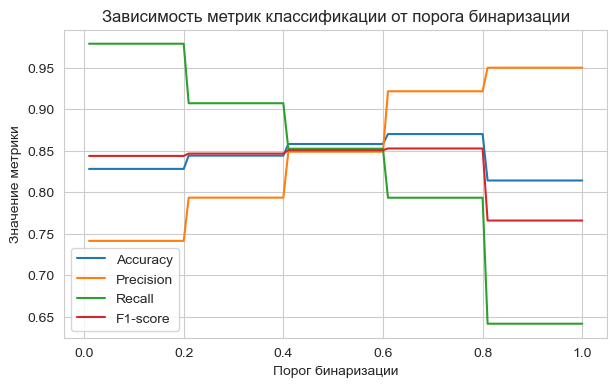

accuracy_defolt = 0.858
threshold = 0.61
accuracy_max = 0.87


In [16]:
X = df.drop(columns = ['high_intensity'])
y = df['high_intensity']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

knn = KNeighborsClassifier()
knn.fit(X_train, y_train)

y_test_pred = knn.predict(X_test)
y_test_pred_proba = knn.predict_proba(X_test)[:, 1]

accuracy_defolt = accuracy_score(y_test, y_test_pred)

thresholds = np.linspace(0.01, 1, 100)

accuracy_list = []
precission_list = []
recall_list = []
f1_list = []

accuracy_max = 0
accuracy_threshold = None

for t in thresholds:
    y_test_pred_t = (y_test_pred_proba >= t).astype(int)
    
    accuracy_list.append(accuracy_score(y_test, y_test_pred_t))
    precission_list.append(precision_score(y_test, y_test_pred_t, zero_division=0))
    recall_list.append(recall_score(y_test, y_test_pred_t))
    f1_list.append(f1_score(y_test, y_test_pred_t, zero_division=0))
    
    if accuracy_score(y_test, y_test_pred_t)>accuracy_max:
        accuracy_max = accuracy_score(y_test, y_test_pred_t)
        accuracy_threshold = t
        
    
    
plt.figure(figsize=(7, 4))

plt.plot(thresholds, accuracy_list, label='Accuracy')
plt.plot(thresholds, precission_list, label='Precision')
plt.plot(thresholds, recall_list, label='Recall')
plt.plot(thresholds, f1_list, label='F1-score')

plt.xlabel('Порог бинаризации')
plt.ylabel('Значение метрики')
plt.title('Зависимость метрик классификации от порога бинаризации')
plt.legend()
plt.grid(True)

plt.show()

print('accuracy_defolt =', accuracy_defolt)
print('threshold =', accuracy_threshold)
print('accuracy_max =', accuracy_max)

>#### Задание 5
Подберите порог бинаризации таким образом, чтобы максимизировать precision классификатора, прогнозирующего продление абонемента.

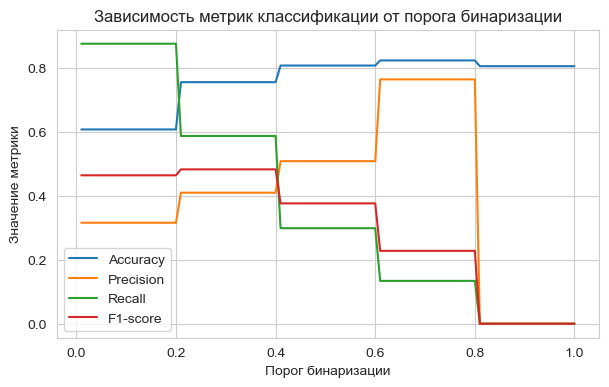

accuracy_defolt = 0.808
threshold = 0.61
accuracy_max = 0.824

precision_defolt = 0.5087719298245614
threshold = 0.61
precision_max = 0.7647058823529411


In [17]:
X = df.drop(columns = ['early_renewal'])
y = df['early_renewal']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

knn = KNeighborsClassifier()
knn.fit(X_train, y_train)

y_test_pred = knn.predict(X_test)
y_test_pred_proba = knn.predict_proba(X_test)[:, 1]

accuracy_defolt = accuracy_score(y_test, y_test_pred)
precision_defolt = precision_score(y_test, y_test_pred)

thresholds = np.linspace(0.01, 1, 100)

accuracy_list = []
precision_list = []
recall_list = []
f1_list = []

accuracy_max = 0
accuracy_threshold = None

precision_max = 0
precision_threshold = None

for t in thresholds:
    y_test_pred_t = (y_test_pred_proba >= t).astype(int)
    
    accuracy_list.append(accuracy_score(y_test, y_test_pred_t))
    precision_list.append(precision_score(y_test, y_test_pred_t, zero_division=0))
    recall_list.append(recall_score(y_test, y_test_pred_t))
    f1_list.append(f1_score(y_test, y_test_pred_t, zero_division=0))
    
    if accuracy_score(y_test, y_test_pred_t)>accuracy_max:
        accuracy_max = accuracy_score(y_test, y_test_pred_t)
        accuracy_threshold = t
        
    if precision_score(y_test, y_test_pred_t)>precision_max:
        precision_max = precision_score(y_test, y_test_pred_t, zero_division=0)
        precision_threshold = t
    
    
plt.figure(figsize=(7, 4))

plt.plot(thresholds, accuracy_list, label='Accuracy')
plt.plot(thresholds, precision_list, label='Precision')
plt.plot(thresholds, recall_list, label='Recall')
plt.plot(thresholds, f1_list, label='F1-score')

plt.xlabel('Порог бинаризации')
plt.ylabel('Значение метрики')
plt.title('Зависимость метрик классификации от порога бинаризации')
plt.legend()
plt.grid(True)

plt.show()

print('accuracy_defolt =', accuracy_defolt)
print('threshold =', accuracy_threshold)
print('accuracy_max =', accuracy_max)
print('')
print('precision_defolt =', precision_defolt)
print('threshold =', precision_threshold)
print('precision_max =', precision_max)

## Домашнее задание

>#### Задание 1
Прочитайте файл `digital_well`.

In [18]:
df = pd.read_csv('data/digital_well.csv')
df

,age,gender,sessions_per_week,subscription_months,therapist_exp_months,avg_session_length_min,completed_module_exercises,has_crisis_call,anxiety_score,high_engagement,churn_risk
0,56,1,0.6,36,91,35.0,3,0,62.4,0,0
1,69,0,1.7,9,146,61.0,44,0,24.6,1,0
2,46,1,5.1,19,0,51.0,50,0,42.7,1,0
3,32,1,3.8,6,0,22.4,17,0,38.3,1,0
4,60,0,0.9,15,128,42.4,28,0,51.2,0,0
...,...,...,...,...,...,...,...,...,...,...,...
1995,27,1,2.4,11,64,83.7,9,0,51.2,1,0
1996,33,1,5.6,14,0,41.3,13,0,61.5,0,0
1997,24,0,1.7,3,52,51.5,45,0,30.2,0,1
1998,34,0,6.8,18,100,58.1,10,0,39.7,1,0


#### Контекст

Сервис психологической поддержки «DigitalWell» анализирует активность пользователей на платформе, чтобы повысить их вовлечённость, удержание и качество подобранных терапевтических методик. На основе данных о поведении пользователей система предсказывает их прогресс.

#### Признаки

- age — возраст пользователя (18–80) (int),

- gender — пол (0 — жен., 1 — муж.) (int),

- sessions_per_week — среднее количество терапевтических сессий в неделю (0–7) (float),

- subscription_months — длительность текущей подписки (1–36) (int),

- therapist_exp_months — стаж закреплённого терапевта в месяцах (0 — нет терапевта; иначе 6–240) (int),

- avg_session_length_min — средняя длительность сессии в минутах (20–90) (float),

- completed_module_exercises — количество полностью пройденных упражнений из модулей за последние 30 дней (0–50) (int),

- has_crisis_call — обращался ли на горячую линию за последние 30 дней (0 — нет, 1 — да) (int).


#### Таргеты


- anxiety_score — уровень тревожности по принятой в DigitalWell шкале (20–80 баллов) (float), 
- high_engagement — высокая вовлечённость: регулярное посещение сессий, соблюдение расписания (>4 сессий в неделю + модульные упражнения) (int)
- churn_risk — риск оттока: пользователь прекратил подписку в течение 2 месяцев после окончания текущей подписки (int). 

#### Бизнес-задачи

- anxiety_score → персонализация контента (какие модули, упражнения, техники предлагать),

- high_engagement → оптимизация нагрузки на терапевтов, выделение «звёздных» пользователей,

- churn_risk → раннее выявление уходящих клиентов, запуск реактивационных кампаний.

>#### Задание 2
Обучите регрессионную модель, которая прогнозирует уровень тревожности. Вычислите ее метрики на train'е и на test'е. При вычислении метрик используйте 1) ручной подсчет по определению, 2) методы билиотеки sklearn. Убедитесь, что метрики совпадают с точностью до шестого знака после запятой.

In [19]:
# Код

>#### Задание 3
Обучите бинарный классификатор, который прогнозирует вовлеченность пользователя. Вычислите его метрики на train'е и на test'е. При вычислении метрик используйте 1) ручной подсчет по определению, 2) методы билиотеки sklearn. Убедитесь, что метрики совпадают с точностью до шестого знака после запятой.

In [20]:
# Код

>#### Задание 4
Подберите порог бинаризации таким образом, чтобы максимизировать accuracy классификатора, прогнозирующего вовлеченность пользователя.

In [21]:
# Код

>#### Задание 5
Подберите порог бинаризации таким образом, чтобы максимизировать precision классификатора, прогнозирующего уход пользователя.

In [22]:
# Код